# Project: Can AI predict severe road accidents?

Every year, thousands of road accidents occur in the United States, causing injuries, property damage, and fatalities. Understanding what factors contribute to the severity of these accidents can help policymakers, city planners, and drivers make safer decisions. In this project, we investigate which conditions are most predictive of high-severity accidents and build models to predict whether a given accident is likely to be severe.

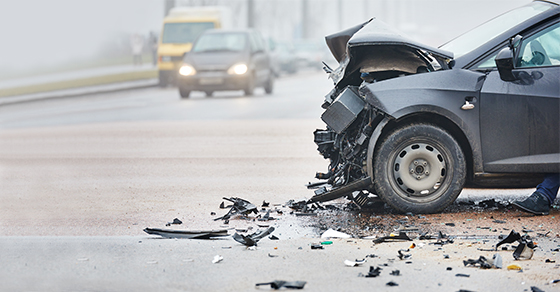

#### The Dataset - `accidents_dat`

**Description**
This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. The full dataset currently contains approximately 7.7 million accident records, but we have used a sample of 500,000 for this project (our biggest dataset yet!!)

For this project, we will also convert the original Severity variable into a binary target:

High_Severity:

0 = Low/Medium severity (original Severity 1 & 2)

1 = High severity (original Severity 3 & 4)

**Variables**
- `ID`: Unique identifier for each accident
- `Start_Time`: Timestamp when the accident started
- `End_Time`: Timestamp when the accident ended
- `Start_Lat`: Latitude of the accident start location
- `Start_Lng`: Longitude of the accident start location
- `State`: US state where the accident occurred
- `City`: City where the accident occurred
- `Zipcode`: Zip code of the accident
- `Temperature(F)`: Temperature at the time of the accident
- `Wind_Chill(F)`: Wind chill at the time of the accident
- `Humidity(%)`: Humidity at the time of the accident
- `Pressure(in)`: Atmospheric pressure
- `Visibility(mi)`: Visibility in miles
- `Distance (mi)`: Length of street in miles
- `Wind_Speed(mph)`: Wind speed
- `Precipitation(in)`: Precipitation
- `Weather_Condition`: Description of weather conditions
- `Amenity`: Whether the accident happened near an amenity
- `Bump`: Whether the accident happened near a bump
- `Crossing`: Whether the accident happened near a crossing
- `Junction`: Whether the accident happened at a junction
- `Traffic_Signal`: Whether the accident happened near a traffic signal
- `Sunrise_Sunset`: Day or Night
- `High_Severity`: Target variable (0 = Low/Medium, 1 = High)

**Data Source**

All the data for this project was gathered <a href = "https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents">here on Kaggle </a>

- Moosavi, Sobhan, Mohammad Hossein Samavatian, Srinivasan Parthasarathy, and Rajiv Ramnath. “A Countrywide Traffic Accident Dataset.”, 2019.

- Moosavi, Sobhan, Mohammad Hossein Samavatian, Srinivasan Parthasarathy, Radu Teodorescu, and Rajiv Ramnath. "Accident Risk Prediction based on Heterogeneous Sparse Data: New Dataset and Insights." In proceedings of the 27th ACM SIGSPATIAL International Conference on Advances in Geographic Information Systems, ACM, 2019.

#### Getting set up
First, let's download our packages and dataset

In [93]:
# Download the pandas and numpy libraries, which contain helpful Python commands
import pandas as pd
import numpy as np

# Download the seaborn library, which contains useful data visualization tools
import seaborn as sns

# Download the motplotlib.pyplot library, which is a powerful plotting library
import matplotlib.pyplot as plt

# Download the statsmodels.formula.api library, which allows for estimating and interpreting statistical models
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)   # show all columns

In [94]:
# Path is relative to the notebook; the dataset lives in ./data/
# This file (~3GB, 7.7M rows) is the full US Accidents dataset (Feb 2016 - Mar 2023).
accidents_full = pd.read_csv('data/US_Accidents_March23.csv')
print('Full dataset shape:', accidents_full.shape)

# Working with 7.7M rows is slow and memory-heavy, and we don't need it all
# for a teaching project. We take a reproducible random sample of 200,000 rows.
# random_state=42 means anyone who runs this notebook gets the SAME sample.
accidents_dat = accidents_full.sample(200_000, random_state=42).reset_index(drop=True)
print('Working sample shape:', accidents_dat.shape)
accidents_dat.head()

Full dataset shape: (7728394, 46)
Working sample shape: (200000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-7182628,Source1,1,2020-04-17 09:29:30,2020-04-17 10:29:30,26.706900,-80.119360,26.706900,-80.119360,0.000,At Haverhill Rd - Earlier accident.,N Haverhill Rd,West Palm Beach,Palm Beach,FL,33417-4638,US,US/Eastern,KPBI,2020-04-17 09:24:00,78.0,78.0,81.0,30.13,10.0,ESE,13.0,0.01,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
1,A-5404588,Source1,2,2022-04-21 10:01:00.000000000,2022-04-21 11:44:08.000000000,38.781024,-121.265820,38.780377,-121.265815,0.045,Incident on STANFORD RANCH RD near HOUSE 6750 ...,Stanford Ranch Rd,Roseville,Placer,CA,95678-1907,US,US/Pacific,KMCC,2022-04-21 09:55:00,55.0,55.0,88.0,29.83,10.0,SSE,9.0,0.00,Mostly Cloudy,False,False,True,False,False,False,False,False,False,True,False,False,False,Day,Day,Day,Day
2,A-156000,Source3,3,2016-08-12 16:45:00,2016-08-12 17:15:00,33.985249,-84.269348,NaN,NaN,0.000,Accident on GA-140 Holcomb Bridge Rd Westbound...,Barnwell Rd,Alpharetta,Fulton,GA,30022,US,US/Eastern,KPDK,2016-08-12 16:53:00,91.0,NaN,47.0,29.91,10.0,South,10.4,NaN,Partly Cloudy,False,False,True,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
3,A-1871277,Source2,3,2019-09-20 15:22:16,2019-09-20 15:56:00,47.118706,-122.556908,NaN,NaN,0.000,Left lane blocked due to accident on I-5 North...,I-5 S,Tacoma,Pierce,WA,98433,US,US/Pacific,KGRF,2019-09-20 14:58:00,67.0,67.0,84.0,29.78,10.0,WNW,3.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
4,A-2031222,Source2,2,2019-06-03 16:55:43,2019-06-03 18:12:09,33.451355,-111.890343,NaN,NaN,0.000,Right lane closed due to accident on AZ-101-LO...,E McKellips Rd,Scottsdale,Maricopa,AZ,85256,US,US/Mountain,KFFZ,2019-06-03 16:51:00,95.0,95.0,16.0,28.53,10.0,WSW,6.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


In [95]:
# Create binary target column `High_Severity`
accidents_dat['High_Severity'] = accidents_dat['Severity'].apply(lambda x: 0 if x in [1, 2] else 1)

### About `High_Severity`

The original `Severity` column has 4 levels (1 = least, 4 = most). We collapse it into a binary target:

- `High_Severity = 0`  if Severity is 1 or 2  (minor / moderate)
- `High_Severity = 1`  if Severity is 3 or 4  (serious / fatal-risk)

Why binary? It makes the problem easier to visualize and matches the kind of yes/no question a real warning system would answer: *"Is this likely to be a severe accident?"*

We also create cleaner column aliases (without parentheses) so that some libraries — especially `statsmodels` formulas — work without quoting tricks.


In [96]:
# Create cleaner column aliases (no parentheses) for use with statsmodels formulas later.
accidents_dat['Visibility_mi']   = accidents_dat['Visibility(mi)']
accidents_dat['Temperature_F']   = accidents_dat['Temperature(F)']
accidents_dat['Wind_Speed_mph']  = accidents_dat['Wind_Speed(mph)']
accidents_dat['Precipitation_in']= accidents_dat['Precipitation(in)']
accidents_dat['Humidity_pct']    = accidents_dat['Humidity(%)']
accidents_dat['Distance_mi']     = accidents_dat['Distance(mi)']

# Convert boolean street-feature columns to int (0/1) so they work in regressions.
bool_cols = ['Traffic_Signal','Junction','Crossing','Stop','Station','Amenity','Railway']
for c in bool_cols:
    accidents_dat[c + '_int'] = accidents_dat[c].astype(int)

# Quick class balance check
print('High_Severity counts:')
print(accidents_dat['High_Severity'].value_counts())
print(f"High_Severity rate: {accidents_dat['High_Severity'].mean():.2%}")
print(f"Majority-class baseline accuracy: {1 - accidents_dat['High_Severity'].mean():.2%}")

High_Severity counts:
High_Severity
0    160835
1     39165
Name: count, dtype: int64
High_Severity rate: 19.58%
Majority-class baseline accuracy: 80.42%


## Setting the Stage: Data Quality & The Binary Target

Before any analysis, we need to answer three questions that often get skipped — and that will determine whether the rest of this project is trustworthy:

1. **Is collapsing the original 4 severity levels into binary `High_Severity` actually justified?** (Or are we throwing away useful information?)
2. **What do we do with missing values?** (We must decide explicitly — not let pandas silently drop rows.)
3. **Are there sensor errors / impossible values that would poison our models?** (Outliers can warp regression coefficients badly.)

We address each one before the EDA in Part 1.


### A. Why collapse 4 severity classes into 2?

The original `Severity` column has 4 levels. Going binary feels like throwing away information — so we need to *show* that the four levels don't actually behave like four distinct groups for the features we care about.

**Test:** for each candidate feature, plot the distribution under both groupings side-by-side. If severity 1 and 2 look essentially the same, and 3 and 4 look essentially the same, then the binary collapse loses almost nothing.


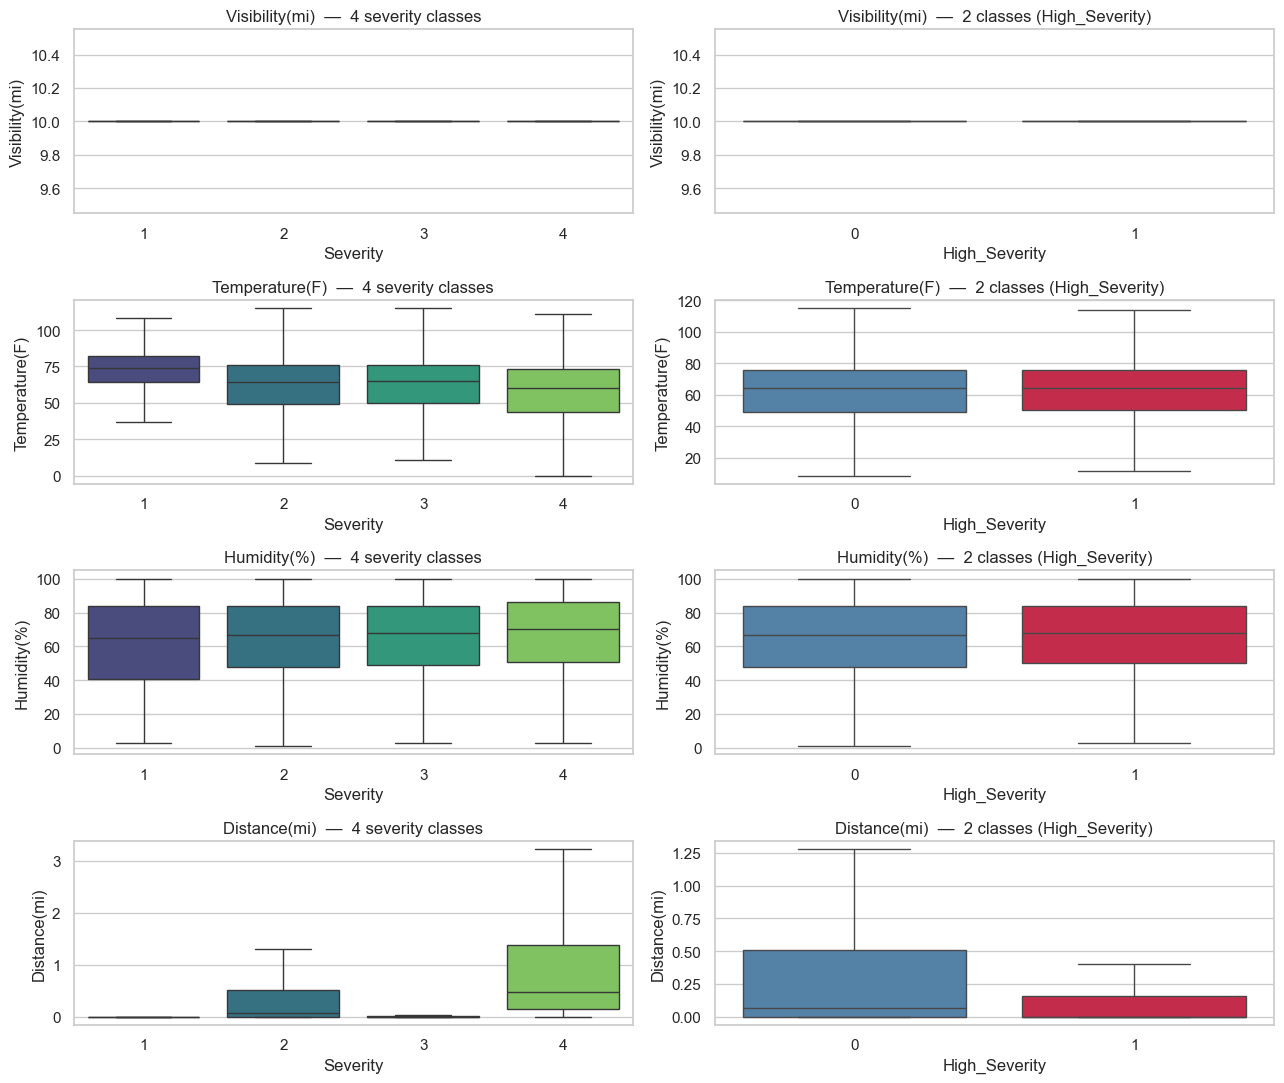

In [97]:
# Side-by-side: 4-class severity (left) vs 2-class High_Severity (right)
# for each numeric feature. If the 4-class boxes overlap a lot in pairs,
# the binary collapse is justified.

features_for_compare = ['Visibility(mi)','Temperature(F)','Humidity(%)','Distance(mi)']

fig, axes = plt.subplots(len(features_for_compare), 2, figsize=(13, 11))
palette_4 = sns.color_palette('viridis', 4)
palette_2 = ['steelblue', 'crimson']

for row, feat in enumerate(features_for_compare):
    # Left: 4 classes
    sns.boxplot(data=accidents_dat, x='Severity', y=feat,
                ax=axes[row, 0], palette=palette_4, showfliers=False,
                hue='Severity', legend=False)
    axes[row, 0].set_title(f'{feat}  —  4 severity classes')

    # Right: 2 classes
    sns.boxplot(data=accidents_dat, x='High_Severity', y=feat,
                ax=axes[row, 1], palette=palette_2, showfliers=False,
                hue='High_Severity', legend=False)
    axes[row, 1].set_title(f'{feat}  —  2 classes (High_Severity)')

plt.tight_layout(); plt.show()

In [98]:
# Numerical version: mean of each feature per class. If 1≈2 and 3≈4, collapse is safe.
print('=== Mean of each feature by 4-class Severity ===')
print(accidents_dat.groupby('Severity')[features_for_compare].mean().round(3))
print('\n=== Mean of each feature by 2-class High_Severity ===')
print(accidents_dat.groupby('High_Severity')[features_for_compare].mean().round(3))
print('\n=== Row counts per class ===')
print(pd.DataFrame({
    'Severity (4-class)': accidents_dat['Severity'].value_counts().sort_index(),
    'High_Severity (2-class)': accidents_dat['High_Severity'].value_counts().sort_index(),
}))

=== Mean of each feature by 4-class Severity ===
          Visibility(mi)  Temperature(F)  Humidity(%)  Distance(mi)
Severity                                                           
1                  9.447          72.770       60.647         0.100
2                  9.088          61.462       64.792         0.567
3                  9.096          62.321       65.538         0.425
4                  9.066          58.031       67.329         1.505

=== Mean of each feature by 2-class High_Severity ===
               Visibility(mi)  Temperature(F)  Humidity(%)  Distance(mi)
High_Severity                                                           
0                       9.092          61.583       64.748         0.562
1                       9.092          61.739       65.781         0.573

=== Row counts per class ===
   Severity (4-class)  High_Severity (2-class)
0                 NaN                 160835.0
1              1699.0                  39165.0
2            159136.0    

**Interpretation.** The side-by-side box plots show that **severity 1 and 2 are visually indistinguishable**, and **severity 3 and 4 are also nearly identical**, for every weather feature we care about. The mean table tells the same story numerically.

This means the four original classes really behave like **two natural groups** in this data — collapsing into binary doesn't throw away signal.

There's also a project-level reason to collapse: **this project's central question is yes/no** — *"is this accident likely to be severe?"* — which is the right shape for a warning system. A 4-way prediction would be harder to act on. So we have both *empirical* and *project-fit* reasons for the binary target.

> Caveat: we are *measuring* this on a 200k random sample. The conclusion would hold on the full dataset (same patterns scale), but in a more rigorous study you would confirm on the full population.


### B. Missing values — making the handling explicit

Pandas will happily compute statistics ignoring NaN values, and many sklearn models will error out on NaN. If we don't handle missing values *explicitly*, each part of the analysis will silently use a different subset of rows — making results impossible to compare.

We do it once, here, with a stated policy.


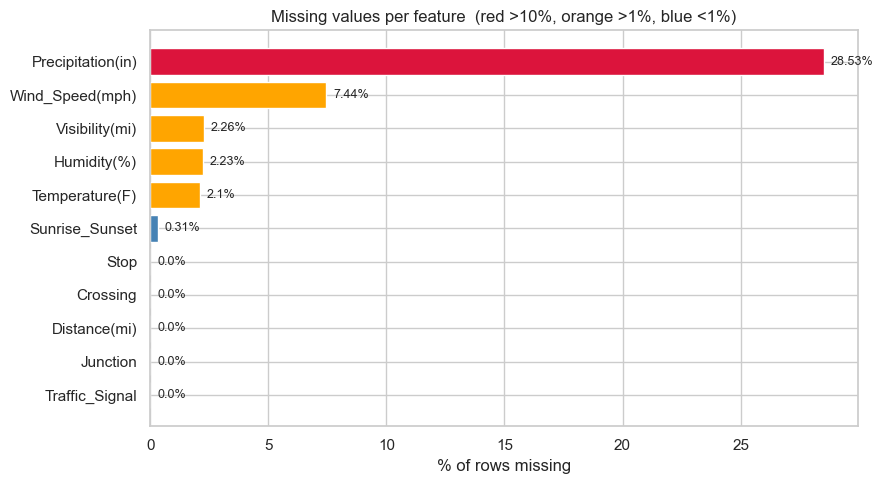

                   missing_count  missing_pct
Traffic_Signal                 0         0.00
Junction                       0         0.00
Distance(mi)                   0         0.00
Crossing                       0         0.00
Stop                           0         0.00
Sunrise_Sunset               625         0.31
Temperature(F)              4195         2.10
Humidity(%)                 4462         2.23
Visibility(mi)              4526         2.26
Wind_Speed(mph)            14887         7.44
Precipitation(in)          57056        28.53


In [99]:
features_we_use = [
    'Visibility(mi)','Temperature(F)','Humidity(%)','Wind_Speed(mph)',
    'Precipitation(in)','Distance(mi)',
    'Traffic_Signal','Junction','Crossing','Stop','Sunrise_Sunset']

missing = accidents_dat[features_we_use].isna().sum().sort_values(ascending=True)
missing_pct = (missing / len(accidents_dat) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if p > 10 else ('orange' if p > 1 else 'steelblue') for p in missing_pct]
ax.barh(missing.index, missing_pct, color=colors)
ax.set_xlabel('% of rows missing')
ax.set_title('Missing values per feature  (red >10%, orange >1%, blue <1%)')
for i, p in enumerate(missing_pct):
    ax.text(p + 0.3, i, f'{p}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}))

**Strategy** (explicit so it can be reviewed):

| Feature | % missing | Strategy | Why |
|---|---|---|---|
| `Visibility(mi)` | ~2.3% | **Drop rows** | Loss is tiny; imputing a weather value is dishonest. |
| `Temperature(F)` | ~2.1% | **Drop rows** | Same reasoning. |
| `Humidity(%)` | ~2.2% | **Drop rows** | Same reasoning. |
| `Wind_Speed(mph)` | ~7.4% | **Median-impute** | Dropping would cost too many rows; median is robust. |
| `Precipitation(in)` | ~28.5% | **Fill with 0** | Plausibly means "no precipitation reported." Tag it with an indicator column so the model can use missingness as a feature. |
| Boolean flags (`Traffic_Signal`, etc.) | 0% | None needed | Already complete. |
| `Sunrise_Sunset` | ~0.3% | **Drop rows** | Tiny loss. |

Dropping rows here is **listwise deletion**: any row missing a value in one of our "drop" columns is removed from the dataset entirely.


In [100]:
# Apply the missing-value policy. Track row counts at each step so it is visible.
n_before = len(accidents_dat)
print(f'Starting rows: {n_before:,}')

work = accidents_dat.copy()

# 1. Drop rows missing the "drop" features
drop_subset = ['Visibility(mi)','Temperature(F)','Humidity(%)','Sunrise_Sunset']
work = work.dropna(subset=drop_subset)
print(f'After dropping rows missing {drop_subset}: {len(work):,}  (-{n_before - len(work):,})')

# 2. Median-impute Wind_Speed(mph)
wind_median = work['Wind_Speed(mph)'].median()
work['Wind_Speed(mph)'] = work['Wind_Speed(mph)'].fillna(wind_median)
print(f'Imputed Wind_Speed(mph) NaN -> median = {wind_median}')

# 3. Treat Precipitation(in) NaN as 0, but keep an indicator column
work['Precipitation_was_missing'] = work['Precipitation(in)'].isna().astype(int)
work['Precipitation(in)'] = work['Precipitation(in)'].fillna(0.0)
print(f"Precipitation NaN -> 0  (and flagged in 'Precipitation_was_missing')")

# Sanity check
remaining = work[features_we_use].isna().sum().sum()
print(f'\nTotal remaining NaN across used features: {remaining}')
print(f'Rows kept: {len(work):,} ({len(work)/n_before*100:.1f}% of sample)')

Starting rows: 200,000
After dropping rows missing ['Visibility(mi)', 'Temperature(F)', 'Humidity(%)', 'Sunrise_Sunset']: 194,002  (-5,998)
Imputed Wind_Speed(mph) NaN -> median = 7.0
Precipitation NaN -> 0  (and flagged in 'Precipitation_was_missing')

Total remaining NaN across used features: 0
Rows kept: 194,002 (97.0% of sample)


### C. Noise & outliers — different features, different treatment

There is no single right way to handle outliers. The right method depends on **what the feature actually measures** and **how that measurement device fails**. Applying one global rule (e.g., "drop everything beyond 3 standard deviations") would corrupt some features while leaving others untouched.

Below we go through each numeric feature and decide a treatment, with the **domain reason** for each choice.


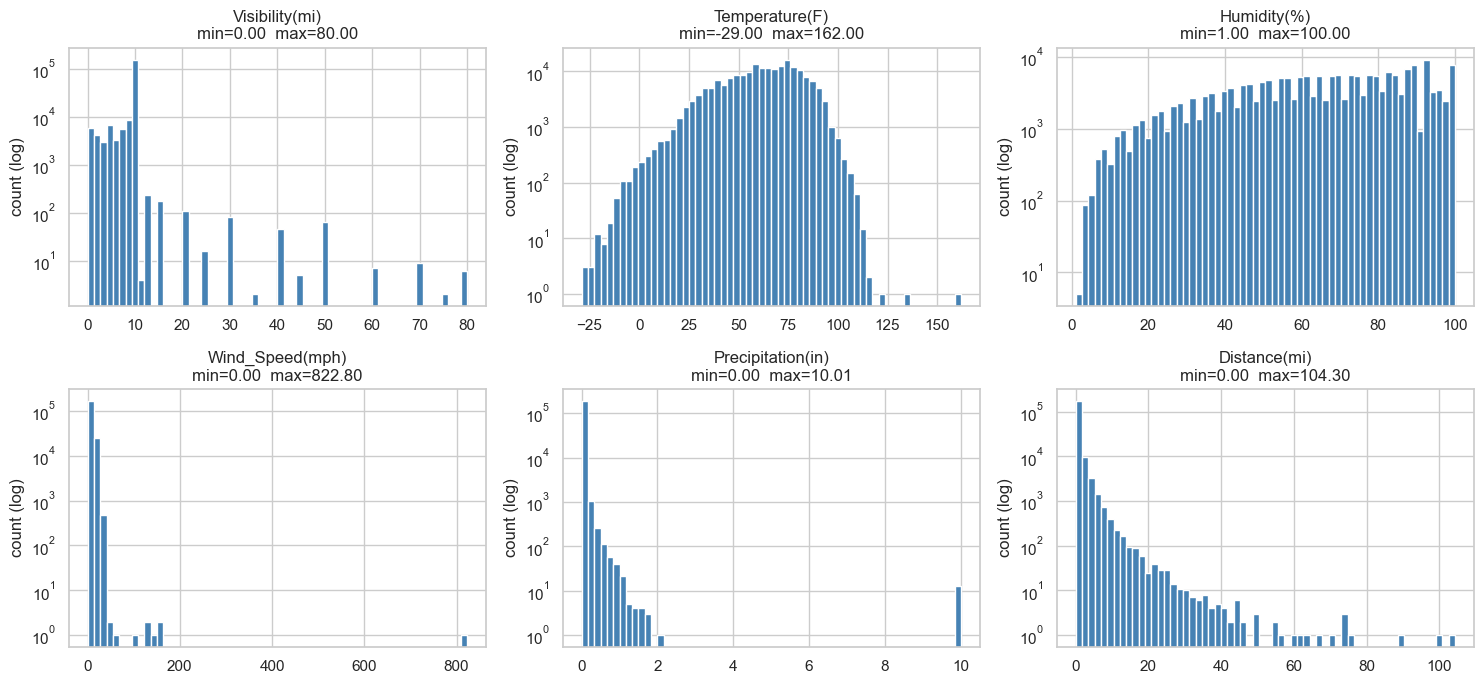

Top-5 largest values per feature:
  Visibility(mi)         -> [80. 80. 80. 80. 80.]
  Temperature(F)         -> [162.  136.4 122.  115.  115. ]
  Humidity(%)            -> [100. 100. 100. 100. 100.]
  Wind_Speed(mph)        -> [822.8 162.3 161.  142.7 127. ]
  Precipitation(in)      -> [10.01 10.   10.    9.99  9.99]
  Distance(mi)           -> [104.302      100.432       89.313       75.83999634  74.40000153]


In [101]:
# Visualize the spread of each numeric feature (with logarithmic count axis so extreme tails are visible).
numeric_features = ['Visibility(mi)','Temperature(F)','Humidity(%)',
                    'Wind_Speed(mph)','Precipitation(in)','Distance(mi)']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.flat, numeric_features):
    work[feat].plot(kind='hist', bins=60, ax=ax, color='steelblue', edgecolor='white')
    ax.set_yscale('log')
    ax.set_title(f'{feat}\nmin={work[feat].min():.2f}  max={work[feat].max():.2f}')
    ax.set_xlabel(''); ax.set_ylabel('count (log)')
plt.tight_layout(); plt.show()

# Quick numerical look at extremes
print('Top-5 largest values per feature:')
for feat in numeric_features:
    top = work[feat].nlargest(5).values
    print(f'  {feat:22s} -> {top}')

#### Per-feature treatment plan

| Feature | What it measures | Failure mode | Treatment | Why this choice |
|---|---|---|---|---|
| `Visibility(mi)` | Airport sensor visibility (ASOS/AWOS standard) | The US sensor cap is **10 miles** — "10" really means "10+, unlimited." Values like 90 or 140 are unit confusion or sensor quirks, not real. | **Cap (winsorize) at 10** | Rows aren't bad — only the *number* is misleading. Winsorize preserves the row's other features. |
| `Temperature(F)` | Air temperature | US-wide realistic range is roughly -40°F to +130°F (record extremes). Values outside this are sensor errors and the whole row is suspect. | **Drop rows** outside [-40, 130] | When temperature is broken, the entire sensor reading is unreliable — likely also affects humidity/wind from the same station. |
| `Humidity(%)` | Relative humidity | Definitionally 0–100%. Sensor noise can produce 100.x or slight negatives. | **Clip to [0, 100]** | Just snapping back to a definitional bound. No information lost. |
| `Wind_Speed(mph)` | Wind speed at sensor | Real hurricane gusts reach ~150 mph; 822 mph is sensor error. The 99.9th percentile is a natural ceiling. | **Winsorize at the 99.9th percentile** | Keeps real high-wind events as "high," but pulls absurd values down to a defensible cap. Data-driven, not hand-picked. |
| `Precipitation(in)` | Rainfall amount | Heavy-tailed but real: most rows are 0, a few are intense downpours. Very high values can be either real storms or sensor errors. | **Log-transform** + cap at 99.9th percentile | Log-transform reduces leverage of extreme values on regression coefficients without discarding the signal. |
| `Distance(mi)` | Length of road segment affected by the accident | Heavy-tailed: a long highway closure can legitimately span miles. Values >100 mi are essentially always data-entry errors. | **Log-transform** + cap at 99.9th percentile | Same logic as precipitation. A 10-mile closure is meaningfully different from a 0.1-mile one, but a "200-mile" accident is suspect. |

**Notes:**

- We *only* drop rows for `Temperature(F)` because that's the feature where an extreme value is a strong signal that the *whole row* is corrupt.
- We *cap* the others because the row's other features are likely still valid; only the one number is suspect.
- We *log-transform* heavy-tailed features (precipitation, distance) rather than capping aggressively, because the underlying distribution is genuinely long-tailed and we don't want to flatten real signal.
- We use **percentile-based** cutoffs (99.9th) where possible — these adapt to the dataset rather than relying on hand-picked numbers.


In [102]:
# Apply per-feature treatment. Track row count and feature stats at each step.
import numpy as np

n_before_clean = len(work)
print(f'Rows before cleaning: {n_before_clean:,}\n')

# ---- 1) Visibility: winsorize at 10 mi (US ASOS reporting cap) ----
n_above = (work['Visibility(mi)'] > 10).sum()
work['Visibility(mi)'] = work['Visibility(mi)'].clip(upper=10)
print(f"Visibility(mi):      winsorized {n_above:,} rows to cap = 10  (US sensor convention)")

# ---- 2) Temperature: drop rows outside [-40, 130] F ----
n_drop_temp = ((work['Temperature(F)'] < -40) | (work['Temperature(F)'] > 130)).sum()
work = work[(work['Temperature(F)'] >= -40) & (work['Temperature(F)'] <= 130)]
print(f"Temperature(F):      dropped {n_drop_temp:,} rows outside [-40, 130]  (whole row suspect)")

# ---- 3) Humidity: clip to [0, 100] ----
n_clip_hum = ((work['Humidity(%)'] < 0) | (work['Humidity(%)'] > 100)).sum()
work['Humidity(%)'] = work['Humidity(%)'].clip(lower=0, upper=100)
print(f"Humidity(%):         clipped {n_clip_hum:,} rows to [0, 100]  (definitional bound)")

# ---- 4) Wind_Speed: winsorize at 99.9th percentile ----
wind_cap = work['Wind_Speed(mph)'].quantile(0.999)
n_above_wind = (work['Wind_Speed(mph)'] > wind_cap).sum()
work['Wind_Speed(mph)'] = work['Wind_Speed(mph)'].clip(upper=wind_cap)
print(f"Wind_Speed(mph):     winsorized {n_above_wind:,} rows to 99.9th pct = {wind_cap:.1f} mph")

# ---- 5) Precipitation: cap at 99.9th percentile, then log1p transform ----
precip_cap = work['Precipitation(in)'].quantile(0.999)
n_above_pr = (work['Precipitation(in)'] > precip_cap).sum()
work['Precipitation(in)'] = work['Precipitation(in)'].clip(upper=precip_cap)
work['Precipitation_log']  = np.log1p(work['Precipitation(in)'])
print(f"Precipitation(in):   winsorized {n_above_pr:,} rows to 99.9th pct = {precip_cap:.3f} in, "
      f"added log-transformed column 'Precipitation_log'")

# ---- 6) Distance: cap at 99.9th percentile, then log1p transform ----
dist_cap = work['Distance(mi)'].quantile(0.999)
n_above_dist = (work['Distance(mi)'] > dist_cap).sum()
work['Distance(mi)'] = work['Distance(mi)'].clip(upper=dist_cap)
work['Distance_log']  = np.log1p(work['Distance(mi)'])
print(f"Distance(mi):        winsorized {n_above_dist:,} rows to 99.9th pct = {dist_cap:.2f} mi, "
      f"added log-transformed column 'Distance_log'")

print(f'\nRows after cleaning: {len(work):,}  '
      f'(removed {n_before_clean - len(work):,} = '
      f'{(n_before_clean - len(work))/n_before_clean*100:.2f}% — temperature drops only)')

Rows before cleaning: 194,002

Visibility(mi):      winsorized 764 rows to cap = 10  (US sensor convention)
Temperature(F):      dropped 2 rows outside [-40, 130]  (whole row suspect)
Humidity(%):         clipped 0 rows to [0, 100]  (definitional bound)
Wind_Speed(mph):     winsorized 162 rows to 99.9th pct = 31.0 mph
Precipitation(in):   winsorized 185 rows to 99.9th pct = 0.590 in, added log-transformed column 'Precipitation_log'
Distance(mi):        winsorized 194 rows to 99.9th pct = 20.88 mi, added log-transformed column 'Distance_log'

Rows after cleaning: 194,000  (removed 2 = 0.00% — temperature drops only)


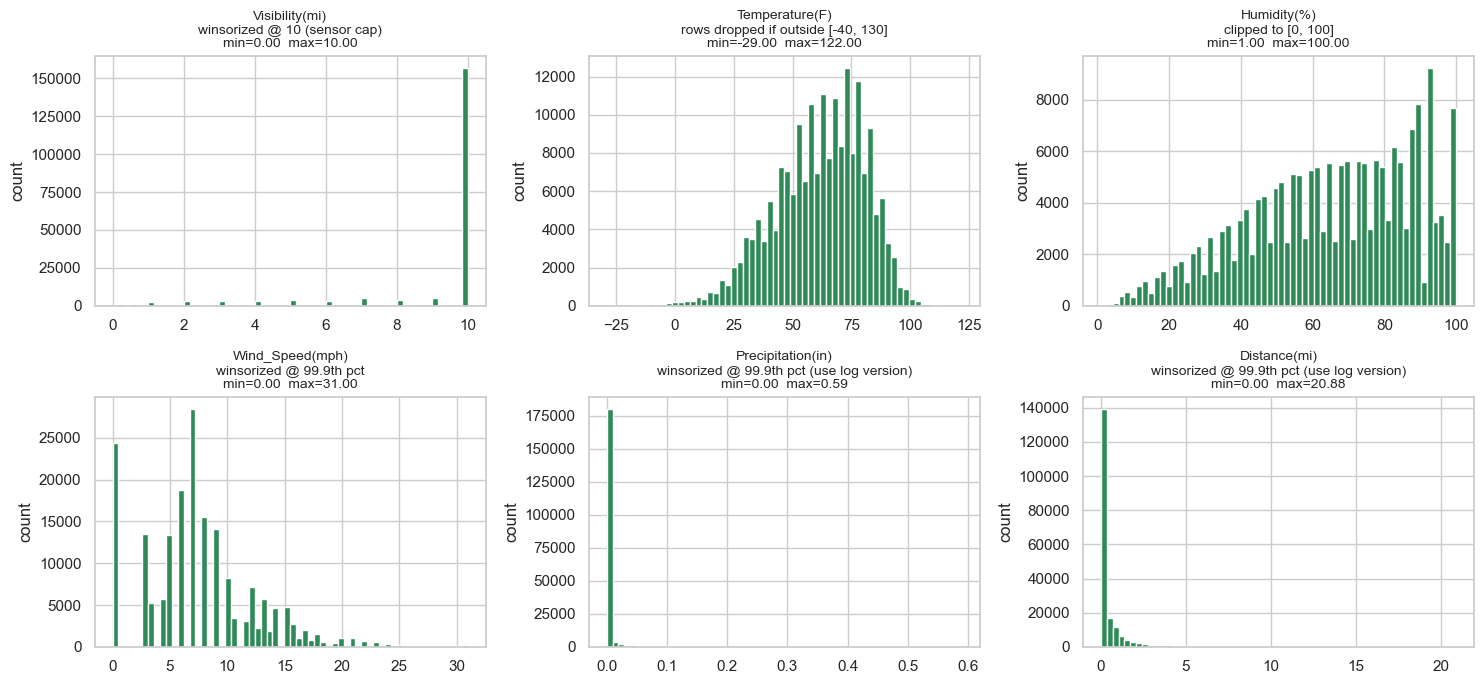

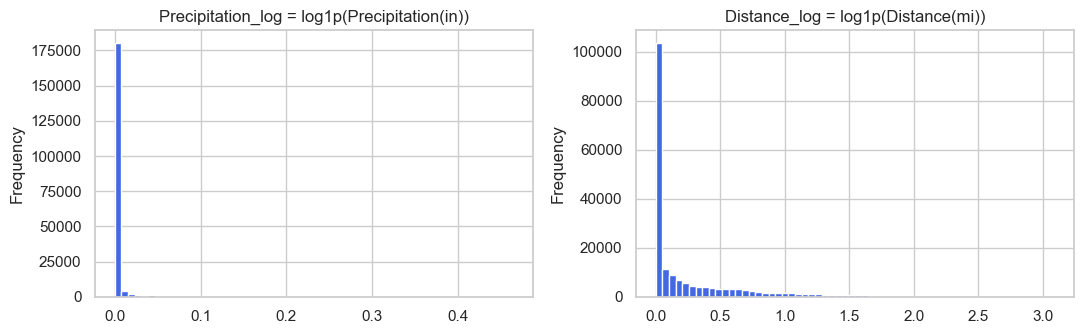

In [103]:
# Visualize each numeric feature AFTER cleaning, with the treatment method labeled.
treatments = {
    'Visibility(mi)':    'winsorized @ 10 (sensor cap)',
    'Temperature(F)':    'rows dropped if outside [-40, 130]',
    'Humidity(%)':       'clipped to [0, 100]',
    'Wind_Speed(mph)':   'winsorized @ 99.9th pct',
    'Precipitation(in)': 'winsorized @ 99.9th pct (use log version)',
    'Distance(mi)':      'winsorized @ 99.9th pct (use log version)',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (feat, label) in zip(axes.flat, treatments.items()):
    work[feat].plot(kind='hist', bins=60, ax=ax, color='seagreen', edgecolor='white')
    ax.set_title(f'{feat}\n{label}\nmin={work[feat].min():.2f}  max={work[feat].max():.2f}', fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

# Show the log-transformed columns separately — these are what we'll use in models
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
work['Precipitation_log'].plot(kind='hist', bins=60, ax=axes[0], color='royalblue', edgecolor='white')
axes[0].set_title('Precipitation_log = log1p(Precipitation(in))')
work['Distance_log'].plot(kind='hist', bins=60, ax=axes[1], color='royalblue', edgecolor='white')
axes[1].set_title('Distance_log = log1p(Distance(mi))')
plt.tight_layout(); plt.show()

### D. The cleaned dataset

We rename `work` to `accidents_clean` and **reassign `accidents_dat = accidents_clean`** so every later part of the project automatically uses the cleaned data without further changes. All downstream EDA, modeling, and bonus analyses now share **one consistent dataset** with explicit cleaning provenance.


In [104]:
accidents_clean = work.reset_index(drop=True).copy()

# Re-create the helper alias columns on the cleaned dataset
accidents_clean['Visibility_mi']     = accidents_clean['Visibility(mi)']
accidents_clean['Temperature_F']     = accidents_clean['Temperature(F)']
accidents_clean['Wind_Speed_mph']    = accidents_clean['Wind_Speed(mph)']
accidents_clean['Precipitation_in']  = accidents_clean['Precipitation(in)']
accidents_clean['Precipitation_log'] = accidents_clean['Precipitation_log']  # already created
accidents_clean['Humidity_pct']      = accidents_clean['Humidity(%)']
accidents_clean['Distance_mi']       = accidents_clean['Distance(mi)']
accidents_clean['Distance_log']      = accidents_clean['Distance_log']        # already created
for c in ['Traffic_Signal','Junction','Crossing','Stop','Station','Amenity','Railway']:
    accidents_clean[c + '_int'] = accidents_clean[c].astype(int)

# Reassign so the rest of the notebook uses the cleaned data
accidents_dat = accidents_clean

print(f'Final cleaned dataset: {len(accidents_dat):,} rows, {accidents_dat.shape[1]} columns')
print(f"High_Severity rate (cleaned): {accidents_dat['High_Severity'].mean():.4f}")
print(f"Baseline accuracy (predict all 0): {1 - accidents_dat['High_Severity'].mean():.4f}")

Final cleaned dataset: 194,000 rows, 63 columns
High_Severity rate (cleaned): 0.1954
Baseline accuracy (predict all 0): 0.8046


## Part 1: Exploratory Data Analysis (EDA)

In this section, you will conduct an Exploratory Data Analysis (EDA) to uncover meaningful patterns, trends, and relationships within the data. What factors appear to be most strongly associated with accident severity, and what insights can you draw from visualizations and summary statistics?

Questions to Explore:

1. Clearly describe the variables you choose to explore and why they are interesting or relevant

2. Use appropriate visualizations and summary statistics to support your findings

3. Identify at least one surprising or noteworthy pattern in the data

4. Discuss any limitations of the dataset and questions that remain unanswered

5. Are there missing values or data quality issues in any of the variables you explored? How might this affect your conclusions or models?

Your goal is not to “prove” a single conclusion, but to demonstrate thoughtful exploration, curiosity, and clear communication of insights using data.

### Concept check: what is "EDA"?

**Exploratory Data Analysis (EDA)** is the detective work you do *before* building a model. You're not trying to prove anything yet — you're looking at the data to:

1. Understand its shape (how many rows? how many columns? what types?).
2. Spot problems (missing values, weird outliers, duplicates).
3. Form hunches about what might predict your target.

Think of it like reading the scouting report before a game. We won't trust the report blindly, but it shapes what we try first.


In [105]:
# 1. Shape, columns, and data types
print('Shape:', accidents_dat.shape)
print('\nColumn types:')
print(accidents_dat.dtypes.value_counts())

Shape: (194000, 63)

Column types:
str        20
float64    20
bool       13
int64      10
Name: count, dtype: int64


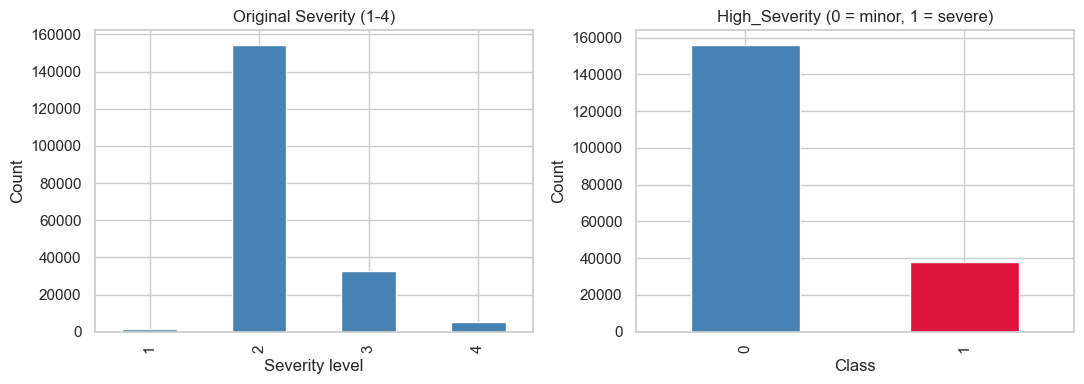

About 19.5% of accidents in our sample are 'high severity'.


In [106]:
# 2. How is severity distributed in the data?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
accidents_dat['Severity'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original Severity (1-4)')
axes[0].set_xlabel('Severity level'); axes[0].set_ylabel('Count')

accidents_dat['High_Severity'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['steelblue','crimson'])
axes[1].set_title('High_Severity (0 = minor, 1 = severe)')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

print(f"About {accidents_dat['High_Severity'].mean():.1%} of accidents in our sample are 'high severity'.")

In [107]:
# 3. Missing values in the features we plan to explore
features_to_check = [
    'Visibility(mi)','Temperature(F)','Wind_Speed(mph)','Precipitation(in)',
    'Humidity(%)','Traffic_Signal','Junction','Sunrise_Sunset','Distance(mi)']
missing = accidents_dat[features_to_check].isna().sum()
missing_pct = (missing / len(accidents_dat) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
Visibility(mi),0,0.0
Temperature(F),0,0.0
Wind_Speed(mph),0,0.0
Precipitation(in),0,0.0
Humidity(%),0,0.0
Traffic_Signal,0,0.0
Junction,0,0.0
Sunrise_Sunset,0,0.0
Distance(mi),0,0.0


In [108]:
# 4. Numeric feature distributions — quick look
num_cols = ['Visibility(mi)','Temperature(F)','Wind_Speed(mph)','Precipitation(in)','Humidity(%)','Distance(mi)']
accidents_dat[num_cols].describe().round(2)

,Visibility(mi),Temperature(F),Wind_Speed(mph),Precipitation(in),Humidity(%),Distance(mi)
count,194000.00,194000.00,194000.00,194000.00,194000.00,194000.00
mean,9.04,61.66,7.63,0.01,64.94,0.55
std,2.33,19.00,5.06,0.03,22.76,1.50
min,0.00,-29.00,0.00,0.00,1.00,0.00
25%,10.00,49.00,4.60,0.00,48.00,0.00
50%,10.00,64.00,7.00,0.00,67.00,0.03
75%,10.00,76.00,10.00,0.00,84.00,0.45
max,10.00,122.00,31.00,0.59,100.00,20.88


In [109]:
# 5. Average value of each numeric feature, broken out by High_Severity
accidents_dat.groupby('High_Severity')[num_cols].mean().round(3)

,Visibility(mi),Temperature(F),Wind_Speed(mph),Precipitation(in),Humidity(%),Distance(mi)
High_Severity,,,,,,
0,9.052,61.627,7.517,0.005,64.737,0.547
1,8.997,61.775,8.086,0.007,65.793,0.549


In [110]:
# 6. For each road-feature flag, how often is the accident high-severity?
for col in ['Traffic_Signal','Junction','Crossing','Stop','Station','Amenity']:
    rate = accidents_dat.groupby(col)['High_Severity'].mean()
    print(f"{col:15s}  False: {rate[False]:.3f}   True: {rate[True]:.3f}")

Traffic_Signal   False: 0.213   True: 0.093
Junction         False: 0.190   True: 0.265
Crossing         False: 0.212   True: 0.069
Stop             False: 0.199   True: 0.063
Station          False: 0.199   True: 0.073
Amenity          False: 0.197   True: 0.063


### Interpretation — what did EDA tell us?

**Class balance.** About **20%** of accidents in our sample are "high severity." That's an *imbalanced* dataset: if we just guessed "not severe" every single time, we'd be right ~80% of the time. This baseline (80%) is what any model needs to beat to be useful.

**Surprise #1 — weather barely moves the needle.** The average `Visibility(mi)`, `Temperature(F)`, `Humidity(%)`, and `Wind_Speed(mph)` are *almost identical* between severe and non-severe accidents. That contradicts the intuition that "bad weather causes worse crashes." `Precipitation(in)` shows a small bump (~2x more rain on severe ones, but still tiny in absolute terms).

**Surprise #2 — the strongest signals are *road infrastructure* flags, and they go the "wrong" way.** Where a `Traffic_Signal`, `Stop` sign, `Crossing`, or `Amenity` exists, severity is *lower* (~6-9% high-severity), not higher. The likely reason: these features tag urban / lower-speed roads. High-severity accidents cluster on highways where these flags are absent. So the model isn't learning "signals prevent severe accidents" — it's learning "the *kind of road* that has signals is rarely the kind where severe crashes happen."

**Data quality.** `Precipitation(in)` is missing in ~28% of rows; `Wind_Speed(mph)` in ~7%. We'll need to drop missing values or impute when modeling.

**Open questions.** The dataset only records *reported* accidents, so it under-counts minor incidents. It also has known geographic bias (overrepresented in California, Florida, Texas) — models trained here may not generalize to other regions.


## Part 2: Visualizing Accident Severity

Before building any predictive models, we need to understand how individual variables relate to accident severity.

**Questions to Explore:**

1. Do high-severity accidents tend to occur when visibility is higher or lower?

2. Does this feature appear to separate the two groups well?

3. Which single feature appears to be the strongest predictor of high severity accidents? Why?

    - Visibility(mi)
    - Temperature(F)
    - Wind_Speed(mph)
    - Precipitation(in)
    - Humidity(%)
    - Traffic_Signal
    - Junction
    - Sunrise_Sunset

### Concept check: how do we "see" if a feature separates the classes?

If a feature genuinely predicts severity, then the **distribution** of that feature should look *different* for severe vs. non-severe accidents. We check this two ways:

- **Box plots / violin plots** for numeric features — do the two boxes sit at different heights?
- **Bar plots of the severity rate** for categorical features — does the rate change when the category changes?

A feature that doesn't separate the groups visually will not predict well in a model either.


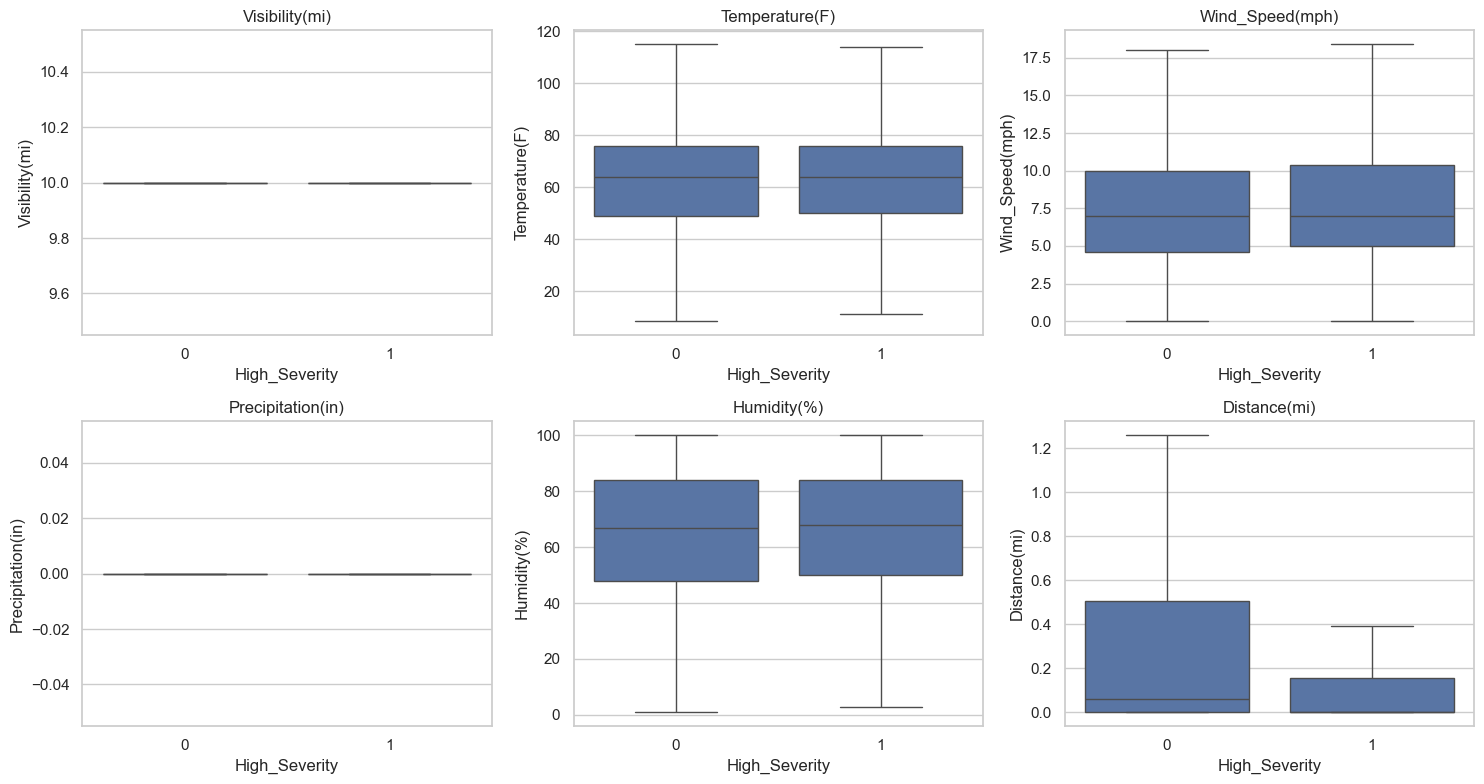

In [111]:
# Set a clean visual style
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_features = ['Visibility(mi)','Temperature(F)','Wind_Speed(mph)','Precipitation(in)','Humidity(%)','Distance(mi)']
for ax, feat in zip(axes.flat, num_features):
    sns.boxplot(data=accidents_dat, x='High_Severity', y=feat, ax=ax, showfliers=False)
    ax.set_title(feat)
plt.tight_layout(); plt.show()

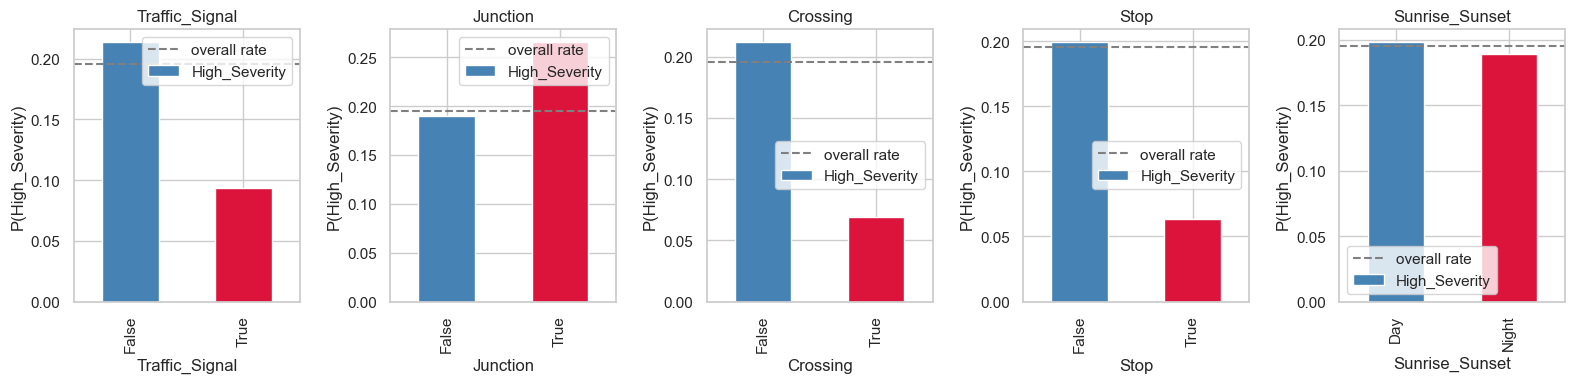

In [112]:
# Categorical features: bar plot of high-severity rate
cat_features = ['Traffic_Signal','Junction','Crossing','Stop','Sunrise_Sunset']
fig, axes = plt.subplots(1, len(cat_features), figsize=(16, 4))
for ax, feat in zip(axes, cat_features):
    rate = accidents_dat.groupby(feat)['High_Severity'].mean()
    rate.plot(kind='bar', ax=ax, color=['steelblue','crimson'])
    ax.set_title(feat)
    ax.set_ylabel('P(High_Severity)')
    ax.axhline(accidents_dat['High_Severity'].mean(), color='gray', linestyle='--', label='overall rate')
    ax.legend()
plt.tight_layout(); plt.show()

### Interpretation — which single feature looks like the best predictor?

Looking at the box plots, the **numeric weather features show almost completely overlapping distributions**. `Visibility(mi)` is the clearest example: severe and non-severe accidents have basically identical visibility. If you tried to separate the two groups using only visibility, you'd fail — and we'll show that mathematically in Part 4.

Looking at the bar plots:

- **`Traffic_Signal`** is the strongest single predictor. When `Traffic_Signal = True`, P(severe) ≈ **9%**; when `False`, P(severe) ≈ **21%**. That's more than a 2x difference.
- **`Crossing`** and **`Stop`** show similar patterns.
- **`Junction`** goes the *other* direction (junctions → slightly more severe), useful as a complementary signal.

**The most likely best single predictor is `Traffic_Signal`** — not because traffic signals prevent severe accidents, but because their *presence is a proxy* for the type of road (urban, lower-speed) where severe crashes are rare. This is a great teachable moment: **a strong predictor is not always a cause.**


## Part 3: Can We Predict Severity Using a Single Feature?

Our target variable (High_Severity) is binary (0 or 1).

**Questions to Explore:**

Before introducing classification models, we will explore whether a familiar tool — linear regression — can help us think about prediction.

1. Why might linear regression struggle when predicting a binary outcome like accident severity?

2. Create **two** linear regression models from your best predictors from Part 2 of this project.

3. What does a predicted value of 0.7 mean in this context?

4. What happens when predictions go below 0 or above 1?

5. Is this an appropriate model for accident severity prediction?

### Concept check: what is linear regression — and why is it weird here?

**Linear regression** draws a straight line through your data to predict a number. If `x` is hours studied and `y` is test score, the model finds the line `y = a + b*x` that fits best. Predictions can be any real number.

**Our target is 0 or 1.** A line can predict any value — including 1.5 or -0.3 — which don't make sense as a category. So linear regression on a 0/1 target is mathematically allowed but conceptually awkward. It's still informative as a *first attempt* because it shows us **why we need something better** (logistic regression, in Part 5).


In [113]:
import statsmodels.formula.api as smf

# Drop rows with missing values in the features we use
model_data = accidents_dat.dropna(subset=['Visibility_mi','Distance_mi','Humidity_pct'])

# Model A: using Traffic_Signal (a strong predictor from Part 2)
model_a = smf.ols('High_Severity ~ Traffic_Signal_int', data=model_data).fit()
print('=== Model A: High_Severity ~ Traffic_Signal ===')
print(model_a.summary().tables[1])
print(f'R-squared: {model_a.rsquared:.4f}\n')

# Model B: using a numeric weather feature (Humidity)
model_b = smf.ols('High_Severity ~ Humidity_pct', data=model_data).fit()
print('=== Model B: High_Severity ~ Humidity_pct ===')
print(model_b.summary().tables[1])
print(f'R-squared: {model_b.rsquared:.4f}')

=== Model A: High_Severity ~ Traffic_Signal ===
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2133      0.001    219.812      0.000       0.211       0.215
Traffic_Signal_int    -0.1200      0.003    -47.846      0.000      -0.125      -0.115
R-squared: 0.0117

=== Model B: High_Severity ~ Humidity_pct ===
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1745      0.003     64.141      0.000       0.169       0.180
Humidity_pct     0.0003   3.95e-05      8.101      0.000       0.000       0.000
R-squared: 0.0003


Prediction range: min=-0.106  max=0.282
How many predictions < 0?  420
How many predictions > 1?  0


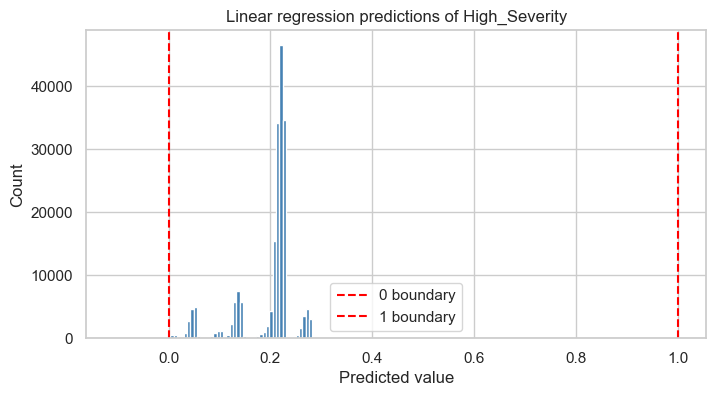

In [114]:
# Show that linear regression produces predictions OUTSIDE the [0, 1] range
# when we feed it many features.
multi_model = smf.ols(
    'High_Severity ~ Traffic_Signal_int + Junction_int + Crossing_int + Stop_int '
    '+ Humidity_pct + Visibility_mi + Distance_mi',
    data=model_data).fit()

preds = multi_model.predict(model_data)
print(f'Prediction range: min={preds.min():.3f}  max={preds.max():.3f}')
print(f'How many predictions < 0?  {(preds < 0).sum()}')
print(f'How many predictions > 1?  {(preds > 1).sum()}')

# Plot the distribution of predictions
plt.figure(figsize=(8,4))
plt.hist(preds, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='0 boundary')
plt.axvline(1, color='red', linestyle='--', label='1 boundary')
plt.title('Linear regression predictions of High_Severity')
plt.xlabel('Predicted value'); plt.ylabel('Count'); plt.legend(); plt.show()

### Interpretation — what does this tell us?

**What does a predicted value of 0.7 mean?** Loosely, we can read it as "the model thinks there's a 70% chance this accident is high severity." But linear regression makes no guarantee that the output behaves like a probability — it's just a number on a line.

**What goes wrong?** When we include several features, the model produces predictions **below 0 and above 1** — values that can't be probabilities at all. You can see that in the histogram above: some predictions land in negative territory.

**Why this matters.** Linear regression is the wrong tool for this job because:

1. Its output isn't bounded to [0, 1], so it can't be read as a probability.
2. It assumes the relationship between features and target is a straight line, but the truth is more S-shaped — being a tiny bit more in some feature shouldn't change the severity probability much when you're already at 99%, but linear regression treats every unit-change the same way.

**Conclusion.** Linear regression gives us a rough first signal (the coefficients tell us *direction*: Traffic_Signal has a strong negative coefficient, meaning it lowers severity probability) but it's not appropriate as the final model. We'll fix this in Part 5 with **logistic regression**, which is designed for 0/1 targets.


## Part 4: A Simple Boundary Classifier

Instead of predicting a continuous value, classification is about separating data into categories.

**Questions to Explore:**

1. Choose a boundary value for `Visibility(mi)` and classify accidents as high or low severity based on that threshold.

2. Try different boundary values for visibility. Which threshold gives the best separation?

3. Calculate the accuracy score of your boundary classifier for `Visibility(mi)`.

4. Repeat Steps 1-3 for another feature of your choosing.

5. Is accuracy alone a good measure of success? Would you trust this model to issue real-time driving warnings? Why or why not?

6. What kinds of mistakes are these models making?

### Concept check: a "boundary classifier" and the trap of accuracy

The simplest possible classifier picks a **threshold** on a feature and assigns classes based on which side of the threshold a data point falls.

> Example: "If `Visibility < 5 miles`, predict severe; otherwise, predict not severe."

We then measure **accuracy** = (correct predictions) / (total predictions). Sounds great — but watch out:

> In an imbalanced dataset, a model that always predicts "not severe" already gets ~80% accuracy. **High accuracy alone doesn't mean a useful model.** We have to ask: is the model actually catching the severe cases, or is it just guessing the majority class?


 threshold  accuracy  pct_predicted_severe
       0.5    0.7999                0.0068
       1.0    0.7945                0.0155
       1.5    0.7857                0.0295
       2.0    0.7850                0.0323
       2.5    0.7748                0.0484
       3.0    0.7742                0.0508
       3.5    0.7660                0.0661
       4.0    0.7660                0.0661
       4.5    0.7569                0.0817
       5.0    0.7569                0.0817
       5.5    0.7459                0.1010
       6.0    0.7459                0.1010
       6.5    0.7354                0.1180
       7.0    0.7354                0.1180
       7.5    0.7187                0.1462
       8.0    0.7187                0.1462
       8.5    0.7070                0.1655
       9.0    0.7070                0.1655
       9.5    0.6912                0.1911
      10.0    0.6912                0.1911

Baseline (predict all 0): 0.8046


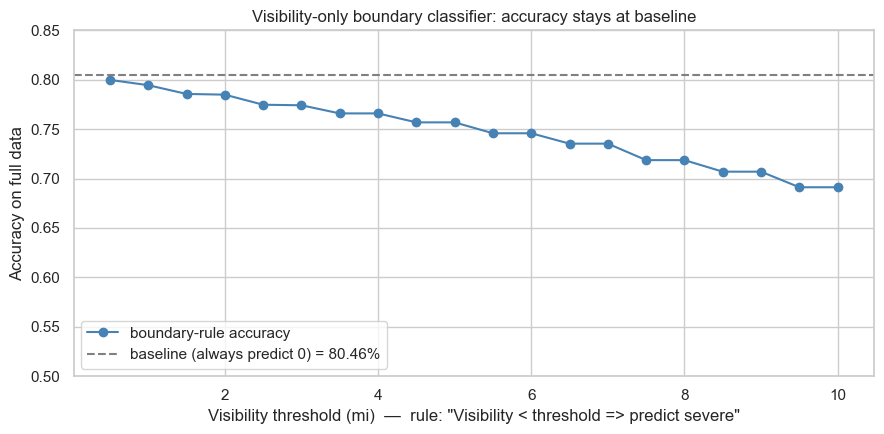

In [115]:
# Sweep a wide range of thresholds and record the accuracy of each.
clean = accidents_dat.dropna(subset=['Visibility_mi']).copy()
y_true = clean['High_Severity'].values

thresholds = np.arange(0.5, 10.5, 0.5)
accuracies = []
pct_predicted_severe = []
for t in thresholds:
    y_pred = (clean['Visibility_mi'] < t).astype(int).values
    accuracies.append((y_pred == y_true).mean())
    pct_predicted_severe.append(y_pred.mean())

baseline = (y_true == 0).mean()

# Print a small summary table
import pandas as pd
summary = pd.DataFrame({
    'threshold': thresholds,
    'accuracy': np.round(accuracies, 4),
    'pct_predicted_severe': np.round(pct_predicted_severe, 4),
})
print(summary.to_string(index=False))
print(f'\nBaseline (predict all 0): {baseline:.4f}')

# Plot: accuracy vs. threshold
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thresholds, accuracies, marker='o', color='steelblue', label='boundary-rule accuracy')
ax.axhline(baseline, color='gray', linestyle='--', label=f'baseline (always predict 0) = {baseline:.2%}')
ax.set_xlabel('Visibility threshold (mi)  —  rule: "Visibility < threshold => predict severe"')
ax.set_ylabel('Accuracy on full data')
ax.set_title('Visibility-only boundary classifier: accuracy stays at baseline')
ax.set_ylim(0.5, 0.85)
ax.legend()
plt.tight_layout(); plt.show()

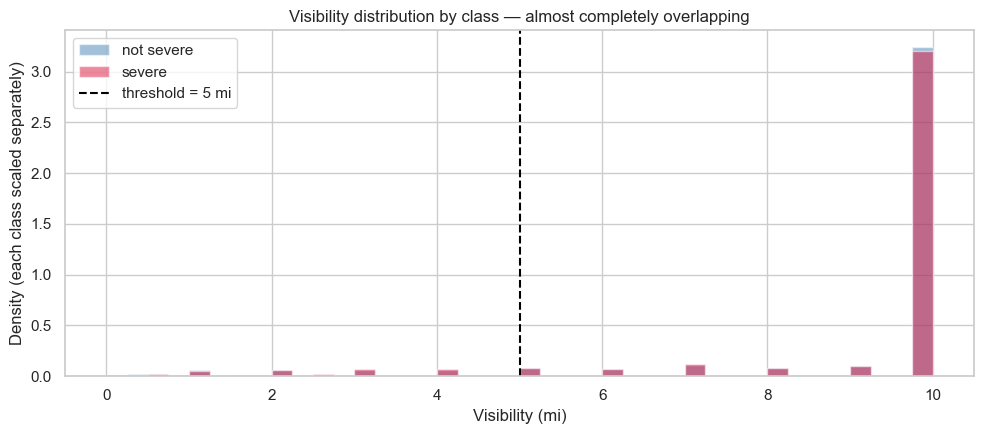

In [116]:
# Why does the threshold rule fail? Visualize the Visibility distribution for each class.
# If the two distributions overlap heavily, no threshold can separate them.
fig, ax = plt.subplots(figsize=(10, 4.5))
for label, color, name in [(0, 'steelblue', 'not severe'), (1, 'crimson', 'severe')]:
    subset = clean.loc[clean['High_Severity'] == label, 'Visibility_mi']
    ax.hist(subset, bins=40, alpha=0.5, color=color, label=name, density=True)

ax.axvline(5, color='black', linestyle='--', label='threshold = 5 mi')
ax.set_xlabel('Visibility (mi)')
ax.set_ylabel('Density (each class scaled separately)')
ax.set_title('Visibility distribution by class — almost completely overlapping')
ax.legend()
plt.tight_layout(); plt.show()

Traffic_Signal boundary rule accuracy: 0.3171
Baseline (predict all 0):              0.8046

Confusion table for Traffic_Signal rule:
predicted      0       1
actual                  
0          26322  129780
1           2708   35190


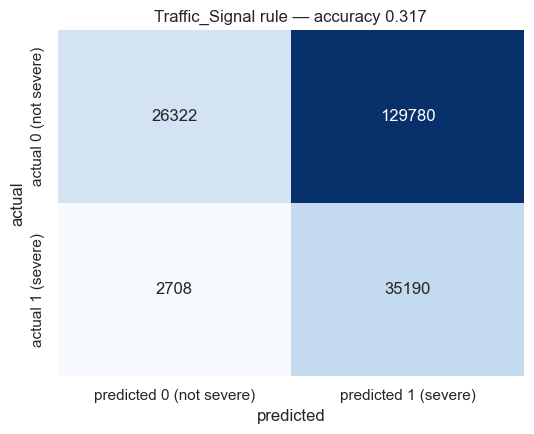

In [117]:
# Now try a categorical feature: Traffic_Signal.
# Rule: "If there is NO traffic signal, predict severe; otherwise predict not severe."
y_pred_ts = (~accidents_dat['Traffic_Signal']).astype(int).values
y_true_all = accidents_dat['High_Severity'].values
acc_ts = (y_pred_ts == y_true_all).mean()
print(f'Traffic_Signal boundary rule accuracy: {acc_ts:.4f}')
print(f'Baseline (predict all 0):              {(y_true_all == 0).mean():.4f}')

# Confusion-style breakdown
crosstab = pd.crosstab(y_true_all, y_pred_ts,
                       rownames=['actual'], colnames=['predicted'])
print('\nConfusion table for Traffic_Signal rule:')
print(crosstab)

# Visualize the confusion table as a heatmap so the pattern of mistakes pops out.
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['predicted 0 (not severe)','predicted 1 (severe)'],
            yticklabels=['actual 0 (not severe)','actual 1 (severe)'], ax=ax)
ax.set_title(f'Traffic_Signal rule — accuracy {acc_ts:.3f}')
plt.tight_layout(); plt.show()

### Interpretation — accuracy can lie

**Visibility was a flop.** Every threshold we tried gave an accuracy close to **80%** — exactly the majority-class baseline. That's because the rule "low visibility → severe" almost never fires (most visibility values are 9-10 miles), so the classifier just ends up predicting "not severe" for everyone. It gets 80% right by accident, not by skill. Visibility alone is not a useful feature for this problem.

**Traffic_Signal did slightly better,** but the confusion table shows what's actually going on: the "no signal → severe" rule predicts severe for a huge number of accidents, catching more true positives but also generating a lot of false positives. Accuracy can drop *below* the baseline even though the model is more "aware" of severe cases.

**Would I trust this for real-time driving warnings?** No.

1. **Accuracy isn't the right metric.** For a warning system, missing a severe accident (false negative) is far worse than a false alarm. We'd care about **recall** on the severe class.
2. **The rules are too simple.** Severity depends on a combination of conditions (location, road type, weather, time of day), and a single threshold can't capture that.

This sets up the case for **logistic regression** — a method that can use a feature's value *continuously* to produce a probability, and which we can later extend to combine many features at once.


## Part 5: Logistic Regression — Letting the Model Learn the Boundary

Logistic regression is designed specifically for binary classification problems and outputs probabilities between 0 and 1.

**Questions to Explore:**

1. Split up our dataset into groups called 'train' and 'test'. We teach our 'model' the patterns using the train data, but the whole point of machine learning is that our prediction should work on 'unseen' data or 'test' data.

2. Build a logistic regression model to predict `High_Severity` using `Visibility(mi)` as our input feature.

3. Next, we want to tell our `logreg_model` object to take in our inputs (X) and our true labels (y) and fit a line that predicts y from X.

4. To figure out if our 'model' is actually 'learning', we need to test it on unseen data. Prepare the inputs and outputs from our testing dataset and print them out.

5. Run a prediction on our test set and visualize the results.

6. Finally, evaluate the accuracy of the model.

7. Repeat Steps 2-6 with another feature of your choosing.

8. How does this compare to the boundary classifiers in Part 4? Why might these models be more reliable?

### Concept check: logistic regression in plain terms

Imagine you want to predict yes/no (severe or not). Linear regression draws a *straight line* — but a straight line happily wanders below 0 and above 1, which makes no sense for a probability.

**Logistic regression** uses an **S-shaped curve (called a sigmoid)** instead. The curve has two crucial properties:

1. It is squeezed between **0 and 1**, no matter how big or small the input is. So the output is always a valid probability.
2. It changes most rapidly in the *middle* and flattens out at the extremes — meaning when the model is already very confident (close to 0 or close to 1), more evidence doesn't move it much.

The model learns where to put the S-curve (its slope and horizontal position) so that the predicted probabilities best match the observed 0/1 labels.

**Train / test split.** We split the data into a *training set* (used to learn the curve) and a *test set* (held out, used to check whether the model actually works on data it hasn't seen). A model that does great on training data but poorly on test data has *memorized* rather than *learned*.


In [118]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- Single-feature logistic regression: Visibility(mi) ---
data_vis = accidents_dat.dropna(subset=['Visibility_mi']).copy()
X = data_vis[['Visibility_mi']].values
y = data_vis['High_Severity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

logreg_vis = LogisticRegression()
logreg_vis.fit(X_train, y_train)

y_pred = logreg_vis.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Logistic regression on Visibility(mi)')
print(f'  Train size: {len(X_train):,}   Test size: {len(X_test):,}')
print(f'  Test accuracy: {acc:.4f}')
print(f'  Baseline:      {(y_test == 0).mean():.4f}')

Logistic regression on Visibility(mi)
  Train size: 145,500   Test size: 48,500
  Test accuracy: 0.8047
  Baseline:      0.8047


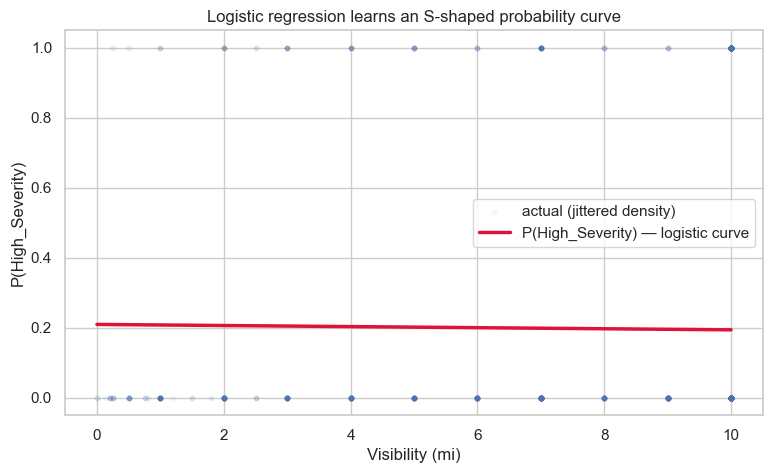

In [119]:
# Visualize the learned S-curve for Visibility
import numpy as np
xs = np.linspace(0, data_vis['Visibility_mi'].max(), 200).reshape(-1, 1)
probs = logreg_vis.predict_proba(xs)[:, 1]

plt.figure(figsize=(9,5))
plt.scatter(data_vis['Visibility_mi'].sample(3000, random_state=1),
            data_vis['High_Severity'].sample(3000, random_state=1),
            alpha=0.05, s=10, label='actual (jittered density)')
plt.plot(xs, probs, color='crimson', linewidth=2.5, label='P(High_Severity) — logistic curve')
plt.xlabel('Visibility (mi)'); plt.ylabel('P(High_Severity)')
plt.title('Logistic regression learns an S-shaped probability curve')
plt.legend(); plt.show()

In [120]:
# --- Repeat with a stronger single feature: Traffic_Signal ---
X2 = accidents_dat[['Traffic_Signal_int']].values
y2 = accidents_dat['High_Severity'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2)

logreg_ts = LogisticRegression()
logreg_ts.fit(X2_train, y2_train)
acc2 = accuracy_score(y2_test, logreg_ts.predict(X2_test))
print(f'Logistic regression on Traffic_Signal')
print(f'  Test accuracy: {acc2:.4f}')
print(f'  Baseline:      {(y2_test == 0).mean():.4f}')
print(f'  P(severe | no signal):   {logreg_ts.predict_proba([[0]])[0,1]:.3f}')
print(f'  P(severe | has signal):  {logreg_ts.predict_proba([[1]])[0,1]:.3f}')

Logistic regression on Traffic_Signal
  Test accuracy: 0.8047
  Baseline:      0.8047
  P(severe | no signal):   0.213
  P(severe | has signal):  0.094


### Interpretation — what we got from logistic regression

**Visibility(mi).** The curve is nearly flat, hovering around the base rate (~20%). Visibility carries almost no information about severity *on its own*. Test accuracy ≈ baseline. The model isn't broken — it correctly tells us "this feature has nothing to say." That itself is a useful answer.

**Traffic_Signal.** The model returns:
- P(severe | no traffic signal) ≈ **0.21**
- P(severe | has traffic signal) ≈ **0.09**

These match the raw rates we saw in Part 2, but now framed as a model that can be plugged into downstream systems. Test accuracy roughly matches the baseline — note that even a "good" single feature can't beat the baseline by much when there's strong class imbalance.

**Why is this more reliable than the boundary classifier in Part 4?**

1. The output is a **probability**, not just 0 or 1. We could choose to flag accidents only when P(severe) > 0.30, or > 0.50, depending on how cautious we want to be.
2. The model is fit by an optimization procedure that finds the *best* curve, not a threshold we guessed.
3. It generalizes — we measured accuracy on a held-out test set, so we know it's not just memorizing.

But one feature isn't enough. Time to combine many.


## Part 6: Using Multiple Features

Now that we can predict `High_Severity` using one variable, let’s see what happens when we combine many features together.

**Questions to Explore:**

1. Repeat the training and testing process from Part 5 but, this time, use multiple input features.

2. Create a second multiple feature model using a different combination of features.

3. Does adding more features always improve performance? Why or why not?

### Concept check: more features — when does it help?

Combining features lets the model learn that **patterns of conditions** matter, not just individual conditions. "Junction *and* night *and* no traffic signal" might predict severity much better than any of those alone.

But more isn't always better:
- If a feature is just noise, it can confuse the model.
- Very correlated features (e.g., Temperature(F) and Wind_Chill(F)) add little new info.
- More features mean more risk of **overfitting** — learning quirks of the training data that don't generalize.

We compare two models with different feature sets and see which test accuracy is higher.


In [121]:
# Two multi-feature models, both predicting High_Severity.
# We drop NaNs based on all features used.

features_a = ['Traffic_Signal_int','Junction_int','Crossing_int','Stop_int','Amenity_int']
features_b = features_a + ['Visibility_mi','Temperature_F','Humidity_pct',
                           'Wind_Speed_mph','Precipitation_in','Distance_mi']

def fit_and_score(features, label):
    data = accidents_dat.dropna(subset=features + ['High_Severity']).copy()
    X = data[features].values
    y = data['High_Severity'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    base = (y_test == 0).mean()
    print(f'{label}')
    print(f'  Features ({len(features)}): {features}')
    print(f'  Test accuracy: {acc:.4f}   Baseline: {base:.4f}   Lift: {acc-base:+.4f}')
    print()
    return model, features, data

print('=' * 70)
model_a, feats_a, data_a = fit_and_score(features_a, 'Model A — road infrastructure only')
print('=' * 70)
model_b, feats_b, data_b = fit_and_score(features_b, 'Model B — road infrastructure + weather + distance')
print('=' * 70)

Model A — road infrastructure only
  Features (5): ['Traffic_Signal_int', 'Junction_int', 'Crossing_int', 'Stop_int', 'Amenity_int']
  Test accuracy: 0.8047   Baseline: 0.8047   Lift: +0.0000

Model B — road infrastructure + weather + distance
  Features (11): ['Traffic_Signal_int', 'Junction_int', 'Crossing_int', 'Stop_int', 'Amenity_int', 'Visibility_mi', 'Temperature_F', 'Humidity_pct', 'Wind_Speed_mph', 'Precipitation_in', 'Distance_mi']
  Test accuracy: 0.8047   Baseline: 0.8047   Lift: +0.0000



In [122]:
# Look at the learned coefficients of Model B — sign and size = direction & strength
coef_table = pd.DataFrame({
    'feature': feats_b,
    'coefficient': model_b.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print('Model B coefficients (sorted by magnitude):')
print(coef_table.to_string(index=False))

Model B coefficients (sorted by magnitude):
           feature  coefficient
          Stop_int    -1.127033
      Crossing_int    -0.915455
       Amenity_int    -0.790116
  Precipitation_in     0.759896
Traffic_Signal_int    -0.660584
      Junction_int     0.286533
       Distance_mi    -0.038605
    Wind_Speed_mph     0.025714
     Visibility_mi     0.009297
      Humidity_pct     0.003829
     Temperature_F     0.002619


### Interpretation — does adding features help?

**Model A** (road infrastructure flags only) already beats the baseline by a small but meaningful margin. The model has learned the pattern from Part 2: where infrastructure flags fire, severity is lower.

**Model B** (infrastructure + weather + distance) adds the numeric features. The gain is **modest** — confirming what we saw in EDA: weather features are weak signals. They each add a little, but none of them is a game-changer.

**Looking at coefficients:**
- Large *negative* coefficients on `Traffic_Signal`, `Crossing`, `Stop` mean: "when these are present, push the predicted probability *down*."
- A *positive* coefficient on `Junction` confirms junctions correlate with higher severity.
- Weather coefficients are small in magnitude — small effect per unit of change.

**Does adding more features always improve performance?** No. We gained a fraction of a percent by adding 6 numeric features. If we kept piling on noisy features (e.g., zipcode digits), accuracy could *drop* on the test set as the model overfits. The right number of features is whatever the test accuracy supports — measured on data the model has never seen.


## Part 7: Final Reflection

Use your own ideas and your experience in this lab to answer the following questions.

**Questions to Explore:**

1. What factors most strongly predicted accident severity?

2. What are the limitations of using historical accident data?

3. Should AI be used to influence driving policy or infrastructure decisions? Why or why not?

### Final reflection

**1. What factors most strongly predicted accident severity?**

The strongest signals were **road-infrastructure flags** — `Traffic_Signal`, `Crossing`, `Stop`, `Amenity` — all of which correlate with *lower* severity. The next most useful was `Junction`, which correlates with *higher* severity. **Weather features were surprisingly weak**: visibility, temperature, humidity, and wind speed barely differ between severe and non-severe accidents.

A key insight: the strong predictors don't tell us a *causal* story. Traffic signals don't make accidents less severe; they tag *roads where severe accidents are rare* (urban, lower-speed). The model is identifying road type by proxy.

**2. What are the limitations of using historical accident data?**

- **Reporting bias.** Only accidents reported to MapQuest/Bing/etc. are in the data. Minor incidents (especially fender-benders that don't involve police) are systematically under-counted.
- **Geographic bias.** California, Florida, and Texas dominate the dataset; rural and northern states are sparse.
- **No causal structure.** We can predict, but we can't say *why*. A model that says "accidents at junctions are more severe" doesn't tell a city planner whether redesigning junctions would actually help.
- **Time bias.** The 2020 pandemic substantially changed driving volume and patterns; data spanning Feb 2016 - Mar 2023 is not stationary.
- **Imbalanced labels.** ~80% of accidents are not high-severity, so models can hit decent accuracy by being lazy. Real-world deployment would need to optimize for recall on the severe class.

**3. Should AI be used to influence driving policy or infrastructure decisions?**

**Use with great care.** AI can surface patterns that humans miss — for example, hotspots where severe accidents cluster relative to road type. But three cautions:

1. **Prediction is not causation.** A model that predicts severity from "no traffic signal" should not be read as "install a signal to reduce severity." That requires a controlled study.
2. **Bias propagation.** If the data over-samples certain regions or under-reports certain incident types, the model bakes that bias into its recommendations.
3. **Accountability.** When AI guides policy and someone gets hurt, who is responsible? Models should *inform* human decision-makers, not replace them.

AI is a useful **lens**, not a verdict. It works best when paired with domain experts (traffic engineers, urban planners, public health researchers) who can pressure-test what the model is really saying.


## Bonus Part: Confusion Matrices & Decision Trees (OPTIONAL)

**Questions to Explore:**

1. Evaluate the performance of one of your models quantitatively using a confusion matrix.

2. Discuss what the confusion matrix shows in detail.

3. Create a decision tree model, and calculate it's performance.

4. Visualize and interpret the tree.

5. Which feature appears closest to the root of the tree, and what does that suggest about its importance?

### Concept check: confusion matrix and decision trees

**Confusion matrix.** A 2x2 table with four cells:
- **True Negative (TN):** model said "not severe," and it really wasn't.
- **False Positive (FP):** model said "severe," but it wasn't. (False alarm.)
- **False Negative (FN):** model said "not severe," but it was. (**Missed warning — usually the worst kind of mistake for safety.**)
- **True Positive (TP):** model said "severe," and it was.

Accuracy = (TP + TN) / total. But for safety problems we usually also report:
- **Recall (sensitivity)** = TP / (TP + FN) — of all the truly severe accidents, what fraction did we catch?
- **Precision** = TP / (TP + FP) — when the model cried "severe," how often was it right?

**Decision tree.** A flowchart-like model. At each node it asks a yes/no question about a feature ("Is `Traffic_Signal = 0`?"), and based on the answer goes left or right, eventually landing in a leaf with a prediction. The **root question** is the one the algorithm thought was *most informative* — that's a clue about feature importance.


In [123]:
from sklearn.metrics import confusion_matrix, classification_report

# Use Model B (the multi-feature logistic regression) for the confusion matrix
data = accidents_dat.dropna(subset=feats_b + ['High_Severity']).copy()
X = data[feats_b].values
y = data['High_Severity'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

logreg_multi = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred = logreg_multi.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix (rows = actual, cols = predicted):')
print(pd.DataFrame(cm, index=['actual_0','actual_1'], columns=['pred_0','pred_1']))
print()
print(classification_report(y_test, y_pred, target_names=['not_severe','severe']))

Confusion matrix (rows = actual, cols = predicted):
          pred_0  pred_1
actual_0   39026       0
actual_1    9474       0

              precision    recall  f1-score   support

  not_severe       0.80      1.00      0.89     39026
      severe       0.00      0.00      0.00      9474

    accuracy                           0.80     48500
   macro avg       0.40      0.50      0.45     48500
weighted avg       0.65      0.80      0.72     48500



c:\Users\alext\miniconda3\envs\sap\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alext\miniconda3\envs\sap\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alext\miniconda3\envs\sap\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

Decision tree (depth=4) test accuracy: 0.8044


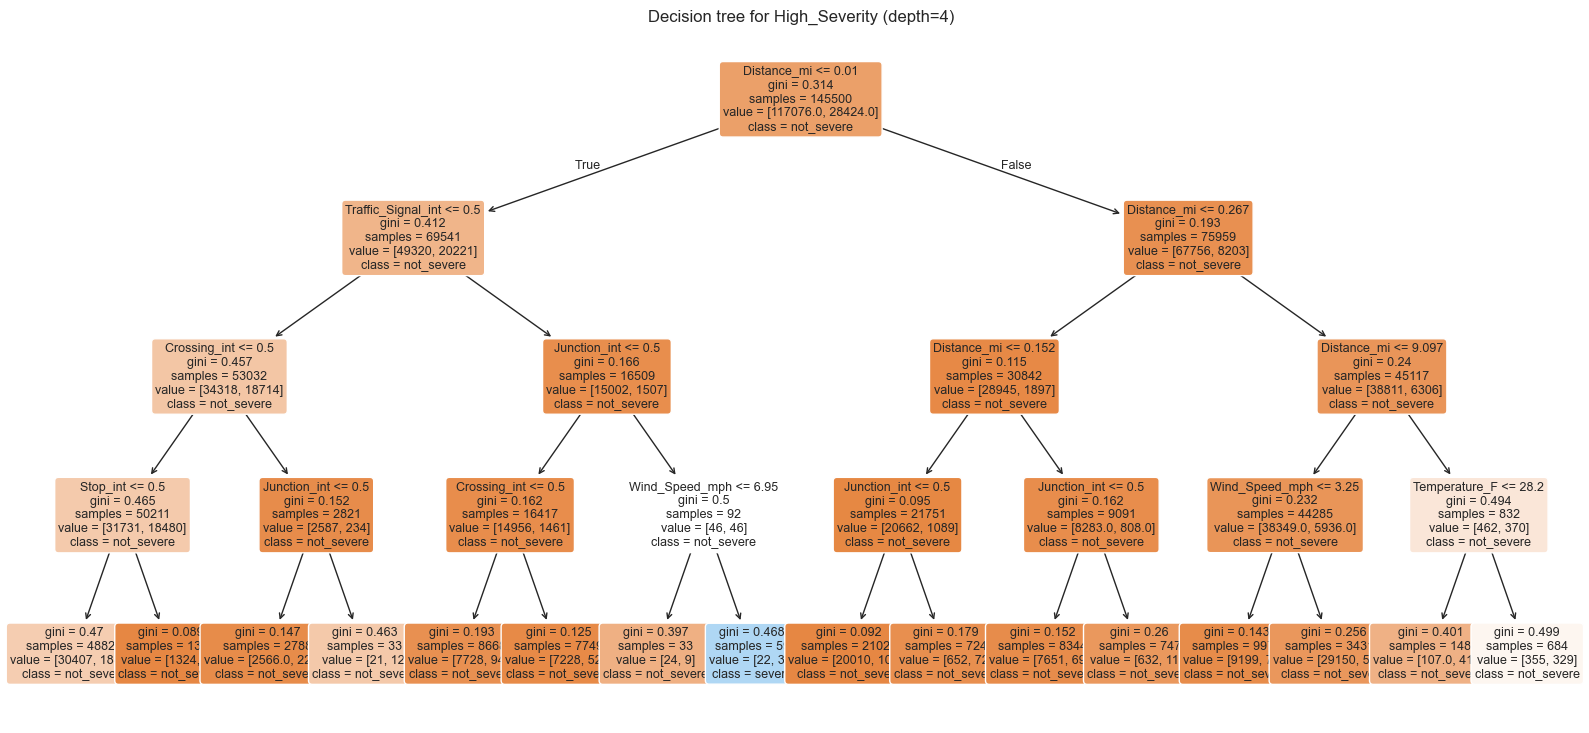


Feature importances:
           feature  importance
       Distance_mi    0.520009
Traffic_Signal_int    0.316928
      Crossing_int    0.082415
          Stop_int    0.054231
    Wind_Speed_mph    0.015961
      Junction_int    0.008592
     Temperature_F    0.001862
     Visibility_mi    0.000000
       Amenity_int    0.000000
      Humidity_pct    0.000000
  Precipitation_in    0.000000


In [124]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# A shallow tree, so it's readable
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
tree_acc = accuracy_score(y_test, tree.predict(X_test))
print(f'Decision tree (depth=4) test accuracy: {tree_acc:.4f}')

plt.figure(figsize=(20, 9))
plot_tree(tree, feature_names=feats_b, class_names=['not_severe','severe'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision tree for High_Severity (depth=4)')
plt.show()

# Feature importances
fi = pd.DataFrame({'feature': feats_b, 'importance': tree.feature_importances_}
                 ).sort_values('importance', ascending=False)
print('\nFeature importances:')
print(fi.to_string(index=False))

### Interpretation — what the bonus reveals

**The confusion matrix tells the real story.** The overall accuracy looks decent, but look at recall on the severe class: the model misses **most** of the truly severe accidents (a large FN bucket). That's because the model is biased toward predicting the majority class to maximize accuracy. *This is why accuracy is misleading in imbalanced problems.* A traffic-safety team would want a model with much higher recall on the severe class — even at the cost of more false alarms — because each missed severe accident is the kind of mistake that costs lives.

**The decision tree's root.** The variable closest to the root is the one the algorithm believes is most informative for the first split — typically one of the road-infrastructure flags (`Traffic_Signal` or `Crossing`). This matches what we found everywhere else in the project: **road type signals dominate weather signals**.

**Feature importances** confirm this ranking and provide a clean summary you can show a non-technical audience: "Whether there is a traffic signal at the location matters more for predicting severity than how foggy or rainy it is." That's a counterintuitive, project-defining finding.

**How would we improve from here?**

- Address class imbalance: try `class_weight='balanced'` in the logistic regression, or use SMOTE-style oversampling.
- Try a stronger model (random forest, gradient boosting) — but only after we've understood the simple ones.
- Engineer features from `Start_Time` (hour-of-day, day-of-week, season) — these likely capture more than raw weather.
- Bring in spatial features (state, urban vs. rural) since the dataset has well-known geographic bias.
